# Traffic Data as Images and Video

**Goal**: Working with image and vide data for object detection. The focus is on how video data can be converted to images, understanding bounding boxes for object classification, and using XML annotations to represent those bounding boxes. 

**Objectives**

- Load and organize the project dataset, seperating images and their corresponding XML annotations. 

- Extract frames from a video at regular intervals.

- Parse XML annotations. 

- Visualize bounding boxes on image data.

In [20]:
import sys
import xml.etree.ElementTree as ET
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt 
from IPython.display import Video
import torch
import torchvision
from torchvision import transforms
from torchvision.io import read_image
from torchvision.transforms.functional import to_pil_image
from torchvision.utils import draw_bounding_boxes, make_grid

In [21]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("CV2 version : ", cv2.__version__)
print("torch version : ", torch.__version__)
print("torchvision version : ", torchvision.__version__)

Platform: win32
Python version: 3.12.1 (tags/v3.12.1:2305ca5, Dec  7 2023, 22:03:25) [MSC v.1937 64 bit (AMD64)]
---
CV2 version :  4.11.0
torch version :  2.5.1+cpu
torchvision version :  0.20.1+cpu


**Exploring Data**

- The project uses the  [Dhaka AI dataset](https://www.kaggle.com/datasets/rifat963/dhakaai-dhaka-based-traffic-detection-dataset?resource=download-directory), which contains images of vehicles in urban traffic scenes from Dhaka, Bangladesh. This dataset is particularly interesting for computer vision as it captures the unique characteristics of Dhaka's busy streets, including a diverse mix of vehicle types and dense traffic conditions.

- We use the dataset for object detection which is a more complex task than image classification. Object detection identifies specific objects within an image (e.g., cars, buses, motorcycles), determines the precise location of these objects, and draws a bounding box around each detected object.

In [22]:
dhaka_image_dir = Path("data_images", "train")

print("Data directory:", dhaka_image_dir)

Data directory: data_images\train


In [23]:
dhaka_files = list(dhaka_image_dir.iterdir())
dhaka_files[-5:]

[WindowsPath('data_images/train/annotations'),
 WindowsPath('data_images/train/images')]

- Counting the file extensions by type:

In [24]:
file_extension_counts = Counter(Path(file).suffix for file in dhaka_files)

for extension, count in file_extension_counts.items():
    print(f"Files with extension {extension}: {count}")

Files with extension : 2


**Seperating images and bounding boxes data**

In [25]:
images_dir = dhaka_image_dir / "images"
annotations_dir = dhaka_image_dir / "annotations"

images_dir.mkdir(exist_ok=True)
annotations_dir.mkdir(exist_ok=True)

Moving files to appropriate directories based on extensions.

In [ ]:
for file in dhaka_files:
    if file.suffix.lower() in (".jpg", ".jpeg", ".png"):
        target_dir = images_dir
    elif file.suffix.lower() == ".xml":
        target_dir = annotations_dir
    file.rename(target_dir / file.name)

Check number of images and annotations:

In [28]:
images_files = list(images_dir.iterdir())
annotations_files = list(annotations_dir.iterdir())

assert len(images_files) == len(annotations_files)

**Annotations**

- Annotations are the labels for the data. Each image has an annotation that contains the coordinates and type of object for each bounding bix in a given image.

- The annotations are stored as XML, which is a way to store structured documents. 

- The ```<annotation>``` tag is the root element, containing all the information about this particular image annotation. The tags within store other information such as ```<folder>```. 

- The most important tag for the current project is the ```<object>```. It describes an object detected in the image, this associated image contains a "bus". 

- The tag ```<bndbox>``` is the bounding box information. 

- There are the coordinates of a rectangle surrounding the bus in the image (in pixels): ```<xmin>``` is the left edge, ```<ymin>``` is the top edge, ```<xmax>``` is the right edge, and ```<ymax>``` is the bottom edge.

In [ ]:
xml_filepath = annotations_dir / "01.xml"
!head -n 25 $xml_filepath

The ElementTree (ET) module in Python can parse an XML file. In XML, the root is the top-level element that contains all other elements. The tag attribute contains the name of the element.

In [30]:
tree = ET.parse(xml_filepath)
root = tree.getroot()
print(root.tag)

annotation


The find method is used to locate the first occurrence of a sub-element with a given tag. Let's find the width and height of the image.

In [31]:
width = int(root.find("size").find("width").text)
height = int(root.find("size").find("height").text)
print(f"image width: {width}  image height: {height}")

image width: 1200  image height: 800


The findall method finds all occurrences of a sub-element within a given tag. We can use that method to get all the relevant data for the bounding boxes.

In [34]:
bounding_boxes = []
labels = []
for obj in root.findall("object"):
    label = obj.find("name").text
    labels.append(label)
    bndbox = obj.find("bndbox")
    xmin = int(bndbox.find("xmin").text)
    ymin = int(bndbox.find("ymin").text)
    xmax = int(bndbox.find("xmax").text)
    ymax = int(bndbox.find("ymax").text)
    bounding_boxes.append([xmin, ymin, xmax, ymax])

for label, bounding_box in zip(labels, bounding_boxes):
    print(f"{label}: {bounding_box}")

bus: [833, 390, 1087, 800]
bus: [901, 284, 1018, 395]
bus: [909, 241, 1010, 287]
rickshaw: [761, 413, 832, 540]
rickshaw: [777, 364, 828, 409]
rickshaw: [120, 351, 177, 423]
rickshaw: [178, 340, 245, 419]
rickshaw: [551, 229, 581, 267]
rickshaw: [849, 211, 870, 240]
rickshaw: [854, 191, 872, 208]
rickshaw: [395, 250, 437, 286]
rickshaw: [626, 209, 653, 240]
motorbike: [863, 241, 882, 268]
car: [218, 252, 289, 285]
car: [495, 216, 531, 244]
car: [485, 201, 520, 219]
three wheelers (CNG): [254, 347, 298, 418]
three wheelers (CNG): [398, 307, 457, 353]
three wheelers (CNG): [240, 290, 303, 344]
pickup: [933, 176, 959, 197]
three wheelers (CNG): [709, 188, 728, 207]
minivan: [575, 213, 600, 244]
car: [530, 212, 549, 237]
minivan: [592, 187, 633, 197]
suv: [616, 198, 654, 212]
suv: [879, 161, 918, 179]
minivan: [850, 151, 882, 166]
rickshaw: [844, 191, 856, 211]
van: [827, 174, 852, 194]
pickup: [410, 226, 452, 252]


**Bounding boxes in PyTorch**

Converting bounding boxes to PyTorch tensors

In [35]:
bboxes_tensor = torch.tensor(bounding_boxes, dtype=torch.float)
print(bboxes_tensor)

tensor([[ 833.,  390., 1087.,  800.],
        [ 901.,  284., 1018.,  395.],
        [ 909.,  241., 1010.,  287.],
        [ 761.,  413.,  832.,  540.],
        [ 777.,  364.,  828.,  409.],
        [ 120.,  351.,  177.,  423.],
        [ 178.,  340.,  245.,  419.],
        [ 551.,  229.,  581.,  267.],
        [ 849.,  211.,  870.,  240.],
        [ 854.,  191.,  872.,  208.],
        [ 395.,  250.,  437.,  286.],
        [ 626.,  209.,  653.,  240.],
        [ 863.,  241.,  882.,  268.],
        [ 218.,  252.,  289.,  285.],
        [ 495.,  216.,  531.,  244.],
        [ 485.,  201.,  520.,  219.],
        [ 254.,  347.,  298.,  418.],
        [ 398.,  307.,  457.,  353.],
        [ 240.,  290.,  303.,  344.],
        [ 933.,  176.,  959.,  197.],
        [ 709.,  188.,  728.,  207.],
        [ 575.,  213.,  600.,  244.],
        [ 530.,  212.,  549.,  237.],
        [ 592.,  187.,  633.,  197.],
        [ 616.,  198.,  654.,  212.],
        [ 879.,  161.,  918.,  179.],
        [ 85

 Create a variable for the image path using pathlib syntax.

In [36]:
image_path = images_dir / "01.jpg"
image = read_image(str(image_path))
print(image.shape)

torch.Size([3, 800, 1200])


Using ```draw_bounding_boxes``` function to add the bounding boxes and labels to the image.

In [37]:
image = draw_bounding_boxes(
    image=image,
    boxes=bboxes_tensor,
    labels=labels,
    width=3,
    fill=False,
    font="arial.ttf",
    font_size=10,
)

Display Image

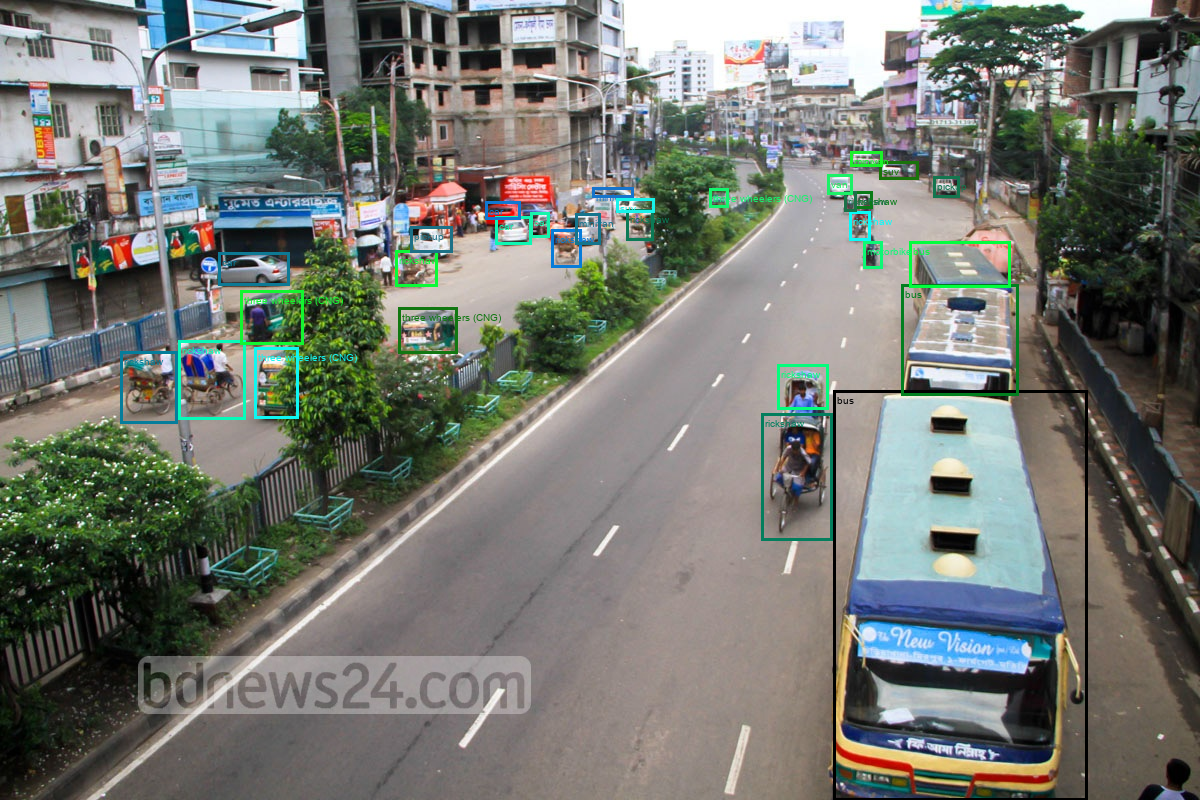

In [38]:
to_pil_image(image)